In [175]:
# importing the relevant python libraries

import pandas as pd
import numpy as np

In [176]:
# load the dataset and print the first five rows

hr = pd.read_csv(r"C:\Users\yawasante\Desktop\all\data cleaning\healthcare_messy_data.csv")
hr.head()

,Patient Name,Age,Gender,Condition,Medication,Visit Date,Blood Pressure,Cholesterol,Email,Phone Number
0,david lee,25,Other,Heart Disease,METFORMIN,1/15/2020,140/90,200.0,name@hospital.org,555-555-5555
1,emily davis,NaN,Male,Diabetes,NONE,5-Apr-18,120/80,200.0,NaN,NaN
2,laura martinez,35,Other,Asthma,METFORMIN,2019.12.01,110/70,160.0,contact@domain.com,NaN
3,michael wilson,NaN,Male,Diabetes,ALBUTEROL,1/15/2020,110/70,NaN,name@hospital.org,555-555-5555
4,david lee,NaN,Female,Asthma,NONE,2/20/2020,110/70,180.0,NaN,


In [177]:
# exploratory analysis
# we will use for loop to check the shape, info, describe

for inspection in ['shape', 'info', 'describe']:
    if inspection == 'shape':
        print('Shape')
        print(hr.shape, end='\n\n')
    elif inspection == 'info':
        print('Info')
        hr.info()
        print()
    elif inspection == 'describe':
        print('Summary statistics')
        print(hr.describe())

Shape
(1000, 10)

Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Patient Name    1000 non-null   object 
 1   Age             841 non-null    object 
 2   Gender          1000 non-null   object 
 3   Condition       794 non-null    object 
 4   Medication      1000 non-null   object 
 5   Visit Date      1000 non-null   object 
 6   Blood Pressure  834 non-null    object 
 7   Cholesterol     769 non-null    float64
 8   Email           616 non-null    object 
 9   Phone Number    821 non-null    object 
dtypes: float64(1), object(9)
memory usage: 78.3+ KB

Summary statistics
       Cholesterol
count    769.00000
mean     189.23277
std       22.28039
min      160.00000
25%      160.00000
50%      180.00000
75%      200.00000
max      220.00000


<small> Now we will start working on each column.</small>  
<small> there are missing values as you can see from the output of the info.</small>  
<small> some of the data types also have to changed for some of the columns.</small>

In [178]:
# we can use the isnull and sum to also check for missing values
hr.isnull().sum()

Patient Name        0
Age               159
Gender              0
Condition         206
Medication          0
Visit Date          0
Blood Pressure    166
Cholesterol       231
Email             384
Phone Number      179
dtype: int64

In [179]:
# before we proceed with the data manipulation, some of the column names have spaces
# we want to replace the space with an underscore(_)
# we will use list comprehension which makes it easy to understand

hr.columns = [col.replace(' ','_') for col in hr.columns]
hr.columns

Index(['Patient_Name', 'Age', 'Gender', 'Condition', 'Medication',
       'Visit_Date', 'Blood_Pressure', 'Cholesterol', 'Email', 'Phone_Number'],
      dtype='object')

In [180]:
# we will start the cleaning process with first column 
hr.head()

,Patient_Name,Age,Gender,Condition,Medication,Visit_Date,Blood_Pressure,Cholesterol,Email,Phone_Number
0,david lee,25,Other,Heart Disease,METFORMIN,1/15/2020,140/90,200.0,name@hospital.org,555-555-5555
1,emily davis,NaN,Male,Diabetes,NONE,5-Apr-18,120/80,200.0,NaN,NaN
2,laura martinez,35,Other,Asthma,METFORMIN,2019.12.01,110/70,160.0,contact@domain.com,NaN
3,michael wilson,NaN,Male,Diabetes,ALBUTEROL,1/15/2020,110/70,NaN,name@hospital.org,555-555-5555
4,david lee,NaN,Female,Asthma,NONE,2/20/2020,110/70,180.0,NaN,


In [181]:
# we have seen that the patient name column has no missing values but the text are not proper.
# lets make the text proper by capitalizing each word, trimming any whitespace.

hr['Patient_Name'] = hr['Patient_Name'].str.strip().str.title()
hr.head()

,Patient_Name,Age,Gender,Condition,Medication,Visit_Date,Blood_Pressure,Cholesterol,Email,Phone_Number
0,David Lee,25,Other,Heart Disease,METFORMIN,1/15/2020,140/90,200.0,name@hospital.org,555-555-5555
1,Emily Davis,NaN,Male,Diabetes,NONE,5-Apr-18,120/80,200.0,NaN,NaN
2,Laura Martinez,35,Other,Asthma,METFORMIN,2019.12.01,110/70,160.0,contact@domain.com,NaN
3,Michael Wilson,NaN,Male,Diabetes,ALBUTEROL,1/15/2020,110/70,NaN,name@hospital.org,555-555-5555
4,David Lee,NaN,Female,Asthma,NONE,2/20/2020,110/70,180.0,NaN,


<small>The patient name column is now proper. we are now moving to the next column age </small>

In [182]:
# lets check the value count

hr['Age'].value_counts(dropna=False) # we add the dropna=False to see the nan values


Age
forty    176
25       171
60       170
35       163
70       161
NaN      159
Name: count, dtype: int64

In [183]:
# 40 is in a text form instead of a number
# lets replace the text with a number as string.
# after that we change the data type to int

hr['Age'] = hr['Age'].str.replace('forty', '40')

hr['Age'].value_counts()

Age
40    176
25    171
60    170
35    163
70    161
Name: count, dtype: int64

In [184]:
hr['Age'] = pd.to_numeric(hr['Age'], errors='coerce').astype('Int64')
hr['Age'].dtype

Int64Dtype()

In [185]:
# let check the summary statisitics of the age column
# to decide on whether to use mean or median value to fill the NaN

hr['Age'].describe()

count        841.0
mean     45.766944
std      16.456303
min           25.0
25%           35.0
50%           40.0
75%           60.0
max           70.0
Name: Age, dtype: Float64

<small>From the summary statistics, we will use the median to fill the missing values.</small>
<small>The mean > median, meaning the age is right skewed (high outliers). Thats why we will use the median</small>

In [186]:
hr['Age'] = hr['Age'].fillna(hr['Age'].median())
hr.head()

,Patient_Name,Age,Gender,Condition,Medication,Visit_Date,Blood_Pressure,Cholesterol,Email,Phone_Number
0,David Lee,25,Other,Heart Disease,METFORMIN,1/15/2020,140/90,200.0,name@hospital.org,555-555-5555
1,Emily Davis,40,Male,Diabetes,NONE,5-Apr-18,120/80,200.0,NaN,NaN
2,Laura Martinez,35,Other,Asthma,METFORMIN,2019.12.01,110/70,160.0,contact@domain.com,NaN
3,Michael Wilson,40,Male,Diabetes,ALBUTEROL,1/15/2020,110/70,NaN,name@hospital.org,555-555-5555
4,David Lee,40,Female,Asthma,NONE,2/20/2020,110/70,180.0,NaN,


In [187]:
hr['Age'].value_counts()

Age
40    335
25    171
60    170
35    163
70    161
Name: count, dtype: Int64

<small>The data type and missing values of the Age column has been resolved.</small>
<small>we procede to the gender column</small>

In [188]:
# first will check it there are missing values
hr['Gender'].value_counts(dropna=False)

Gender
Female    348
Male      343
Other     309
Name: count, dtype: int64

In [189]:
# The gender column has only three values and there is no missing values
# since the values are repeating it's self, we will change the data type to category

hr['Gender'] = hr['Gender'].astype('category')
hr['Gender'].dtype

CategoricalDtype(categories=['Female', 'Male', 'Other'], ordered=False, categories_dtype=object)

In [190]:
hr.head()

,Patient_Name,Age,Gender,Condition,Medication,Visit_Date,Blood_Pressure,Cholesterol,Email,Phone_Number
0,David Lee,25,Other,Heart Disease,METFORMIN,1/15/2020,140/90,200.0,name@hospital.org,555-555-5555
1,Emily Davis,40,Male,Diabetes,NONE,5-Apr-18,120/80,200.0,NaN,NaN
2,Laura Martinez,35,Other,Asthma,METFORMIN,2019.12.01,110/70,160.0,contact@domain.com,NaN
3,Michael Wilson,40,Male,Diabetes,ALBUTEROL,1/15/2020,110/70,NaN,name@hospital.org,555-555-5555
4,David Lee,40,Female,Asthma,NONE,2/20/2020,110/70,180.0,NaN,


In [191]:
# the next column we are going to tackle is the condition column
hr['Condition'].value_counts(dropna=False)

Condition
Asthma           211
Heart Disease    207
NaN              206
Diabetes         205
Hypertension     171
Name: count, dtype: int64

In [192]:
# we will fill the missing value with unknown
# we will then change the data type to category

hr['Condition'] = hr['Condition'].fillna('Unknown').astype('category')
hr['Condition'].dtype

CategoricalDtype(categories=['Asthma', 'Diabetes', 'Heart Disease', 'Hypertension',
                  'Unknown'],
, ordered=False, categories_dtype=object)

In [193]:
# Next is the medication column
hr['Medication'].value_counts(dropna=False)

Medication
ATORVASTATIN    216
METFORMIN       211
NONE            199
ALBUTEROL       187
LISINOPRIL      187
Name: count, dtype: int64

In [194]:
# we will replace the None with Unknown and also change the data type to category

hr['Medication'] = hr['Medication'].astype('category')

hr['Medication'].dtype

CategoricalDtype(categories=['ALBUTEROL', 'ATORVASTATIN', 'LISINOPRIL', 'METFORMIN',
                  'NONE'],
, ordered=False, categories_dtype=object)

In [195]:
hr.head()

,Patient_Name,Age,Gender,Condition,Medication,Visit_Date,Blood_Pressure,Cholesterol,Email,Phone_Number
0,David Lee,25,Other,Heart Disease,METFORMIN,1/15/2020,140/90,200.0,name@hospital.org,555-555-5555
1,Emily Davis,40,Male,Diabetes,NONE,5-Apr-18,120/80,200.0,NaN,NaN
2,Laura Martinez,35,Other,Asthma,METFORMIN,2019.12.01,110/70,160.0,contact@domain.com,NaN
3,Michael Wilson,40,Male,Diabetes,ALBUTEROL,1/15/2020,110/70,NaN,name@hospital.org,555-555-5555
4,David Lee,40,Female,Asthma,NONE,2/20/2020,110/70,180.0,NaN,


In [196]:
# the next column is the Visit date column
# the date format are not uniform, so we have to make it uniform.
# setting format to mixed, makes the date parsing easy

hr['Visit_Date'] = pd.to_datetime(hr['Visit_Date'], errors='coerce', format='mixed')
hr.head()

,Patient_Name,Age,Gender,Condition,Medication,Visit_Date,Blood_Pressure,Cholesterol,Email,Phone_Number
0,David Lee,25,Other,Heart Disease,METFORMIN,2020-01-15,140/90,200.0,name@hospital.org,555-555-5555
1,Emily Davis,40,Male,Diabetes,NONE,2018-04-05,120/80,200.0,NaN,NaN
2,Laura Martinez,35,Other,Asthma,METFORMIN,2019-12-01,110/70,160.0,contact@domain.com,NaN
3,Michael Wilson,40,Male,Diabetes,ALBUTEROL,2020-01-15,110/70,NaN,name@hospital.org,555-555-5555
4,David Lee,40,Female,Asthma,NONE,2020-02-20,110/70,180.0,NaN,


In [197]:
hr['Visit_Date'].isnull().sum()

np.int64(0)

In [198]:
# the next column is Blood pressure
# we will split the blood pressure column to systolic and diastolic
# after that we deal with the data type and missing values

hr[['Systolic', 'Diastolic']] = hr['Blood_Pressure'].str.split('/', expand=True)
hr.head(2)

,Patient_Name,Age,Gender,Condition,Medication,Visit_Date,Blood_Pressure,Cholesterol,Email,Phone_Number,Systolic,Diastolic
0,David Lee,25,Other,Heart Disease,METFORMIN,2020-01-15,140/90,200.0,name@hospital.org,555-555-5555,140,90
1,Emily Davis,40,Male,Diabetes,NONE,2018-04-05,120/80,200.0,NaN,NaN,120,80


<small>Now we will handle the individual split columns</small>

In [199]:
hr['Systolic'].value_counts(dropna=False)

Systolic
140    233
110    211
120    197
130    193
NaN    166
Name: count, dtype: int64

In [200]:
# we first change the systolic data type to numeric
# we will then deal with the NaN

hr['Systolic'] = pd.to_numeric(hr['Systolic'], errors='coerce').astype('Int64')
hr['Systolic'].dtype

Int64Dtype()

In [201]:
hr['Systolic'].describe()

count         834.0
mean     125.371703
std       11.467097
min           110.0
25%           110.0
50%           130.0
75%           140.0
max           140.0
Name: Systolic, dtype: Float64

In [202]:
# from the summary statistics for the systolic, we fill the nan with the median
hr['Systolic'] = hr['Systolic'].fillna(hr['Systolic'].median())
hr['Systolic'].value_counts()

Systolic
130    359
140    233
110    211
120    197
Name: count, dtype: Int64

In [203]:
# we will replicate the systolic process to the diastolic column

hr['Diastolic'] = pd.to_numeric(hr['Diastolic'], errors='coerce').astype('Int64')
hr['Diastolic'].value_counts(dropna=False)

Diastolic
90      233
70      211
80      197
85      193
<NA>    166
Name: count, dtype: Int64

In [204]:
hr['Diastolic'].describe()

count        834.0
mean     81.420863
std       7.554625
min           70.0
25%           70.0
50%           85.0
75%           90.0
max           90.0
Name: Diastolic, dtype: Float64

In [205]:
# we use the median value to fill the Nan
hr['Diastolic'] = hr['Diastolic'].fillna(hr['Diastolic'].median())
hr['Diastolic'].value_counts()

Diastolic
85    359
90    233
70    211
80    197
Name: count, dtype: Int64

In [206]:
hr.head(2)

,Patient_Name,Age,Gender,Condition,Medication,Visit_Date,Blood_Pressure,Cholesterol,Email,Phone_Number,Systolic,Diastolic
0,David Lee,25,Other,Heart Disease,METFORMIN,2020-01-15,140/90,200.0,name@hospital.org,555-555-5555,140,90
1,Emily Davis,40,Male,Diabetes,NONE,2018-04-05,120/80,200.0,NaN,NaN,120,80


In [207]:
# the next column is the cholesterol 
hr['Cholesterol'].value_counts(dropna=False)

Cholesterol
NaN      231
160.0    201
200.0    196
180.0    192
220.0    180
Name: count, dtype: int64

In [208]:
# we will fill the nan with the median value
# after that we will change the cholesterol data type to int from float
hr['Cholesterol'].describe()

count    769.00000
mean     189.23277
std       22.28039
min      160.00000
25%      160.00000
50%      180.00000
75%      200.00000
max      220.00000
Name: Cholesterol, dtype: float64

In [209]:
hr['Cholesterol'] = hr['Cholesterol'].fillna(hr['Cholesterol'].median())
hr['Cholesterol'] = hr['Cholesterol'].astype(int)
hr['Cholesterol'].value_counts()

Cholesterol
180    423
160    201
200    196
220    180
Name: count, dtype: int64

In [210]:
hr.head(2)

,Patient_Name,Age,Gender,Condition,Medication,Visit_Date,Blood_Pressure,Cholesterol,Email,Phone_Number,Systolic,Diastolic
0,David Lee,25,Other,Heart Disease,METFORMIN,2020-01-15,140/90,200,name@hospital.org,555-555-5555,140,90
1,Emily Davis,40,Male,Diabetes,NONE,2018-04-05,120/80,200,NaN,NaN,120,80


In [211]:
# we are now down to the email and phone number columns
# we will fill their NaN with Unknown value

hr['Email'] = hr['Email'].fillna('Unknown')
hr['Phone_Number'] = hr['Phone_Number'].fillna('Unknown')

hr.head()

,Patient_Name,Age,Gender,Condition,Medication,Visit_Date,Blood_Pressure,Cholesterol,Email,Phone_Number,Systolic,Diastolic
0,David Lee,25,Other,Heart Disease,METFORMIN,2020-01-15,140/90,200,name@hospital.org,555-555-5555,140,90
1,Emily Davis,40,Male,Diabetes,NONE,2018-04-05,120/80,200,Unknown,Unknown,120,80
2,Laura Martinez,35,Other,Asthma,METFORMIN,2019-12-01,110/70,160,contact@domain.com,Unknown,110,70
3,Michael Wilson,40,Male,Diabetes,ALBUTEROL,2020-01-15,110/70,180,name@hospital.org,555-555-5555,110,70
4,David Lee,40,Female,Asthma,NONE,2020-02-20,110/70,180,Unknown,,110,70


In [212]:
# we are now down with the necessary manipulation of the data
# we will drop the Blood pressure column and rearrange the columns

hr = hr.drop('Blood_Pressure', axis=1)

cols = ['Patient_Name', 'Age', 'Gender', 'Condition', 'Medication', 'Visit_Date', 'Systolic', 'Diastolic', 'Cholesterol', 'Email', 'Phone_Number']

hr = hr[cols]
hr.head(6)

,Patient_Name,Age,Gender,Condition,Medication,Visit_Date,Systolic,Diastolic,Cholesterol,Email,Phone_Number
0,David Lee,25,Other,Heart Disease,METFORMIN,2020-01-15,140,90,200,name@hospital.org,555-555-5555
1,Emily Davis,40,Male,Diabetes,NONE,2018-04-05,120,80,200,Unknown,Unknown
2,Laura Martinez,35,Other,Asthma,METFORMIN,2019-12-01,110,70,160,contact@domain.com,Unknown
3,Michael Wilson,40,Male,Diabetes,ALBUTEROL,2020-01-15,110,70,180,name@hospital.org,555-555-5555
4,David Lee,40,Female,Asthma,NONE,2020-02-20,110,70,180,Unknown,
5,Mary Clark,40,Male,Hypertension,METFORMIN,2019-03-25,140,90,180,Unknown,Unknown


In [213]:
hr['Phone_Number'].value_counts(dropna=False)

Phone_Number
123-456-7890    245
                200
555-555-5555    193
098-765-4321    183
Unknown         179
Name: count, dtype: int64

In [214]:
# we can see from the value counts that, 200 phone number values are empty
# we will assign it to the unknwon using replace

hr['Phone_Number'] = hr['Phone_Number'].str.replace(' ','Unknown')
hr['Phone_Number'].value_counts(dropna=False)

Phone_Number
Unknown         379
123-456-7890    245
555-555-5555    193
098-765-4321    183
Name: count, dtype: int64

In [215]:
# lets check for the email column too

hr['Email'].value_counts(dropna=False)

Email
Unknown                384
contact@domain.com     217
patient@example.com    203
name@hospital.org      196
Name: count, dtype: int64

In [216]:
# lets standardize the Medication column by capitalizing only the first letter
hr['Medication'] = hr['Medication'].str.title()

In [217]:
hr.head(10)

,Patient_Name,Age,Gender,Condition,Medication,Visit_Date,Systolic,Diastolic,Cholesterol,Email,Phone_Number
0,David Lee,25,Other,Heart Disease,Metformin,2020-01-15,140,90,200,name@hospital.org,555-555-5555
1,Emily Davis,40,Male,Diabetes,None,2018-04-05,120,80,200,Unknown,Unknown
2,Laura Martinez,35,Other,Asthma,Metformin,2019-12-01,110,70,160,contact@domain.com,Unknown
3,Michael Wilson,40,Male,Diabetes,Albuterol,2020-01-15,110,70,180,name@hospital.org,555-555-5555
4,David Lee,40,Female,Asthma,None,2020-02-20,110,70,180,Unknown,Unknown
5,Mary Clark,40,Male,Hypertension,Metformin,2019-03-25,140,90,180,Unknown,Unknown
6,Robert Brown,40,Male,Hypertension,Lisinopril,2020-02-20,120,80,180,name@hospital.org,Unknown
7,David Lee,60,Other,Unknown,None,2020-02-20,130,85,180,name@hospital.org,Unknown
8,Laura Martinez,60,Other,Heart Disease,None,2020-01-15,140,90,180,name@hospital.org,Unknown
9,Michael Wilson,40,Female,Unknown,Albuterol,2020-02-20,140,90,220,patient@example.com,555-555-5555


In [218]:
# the last task is to check for duplicates
hr[hr.duplicated()]

,Patient_Name,Age,Gender,Condition,Medication,Visit_Date,Systolic,Diastolic,Cholesterol,Email,Phone_Number


### There is no duplicates. The data now is ready for any analysis

In [219]:
import matplotlib.pyplot as plt
import seaborn as sns

### we will do some basic visualization of the age, gender, condition and medication

<Figure size 500x500 with 0 Axes>

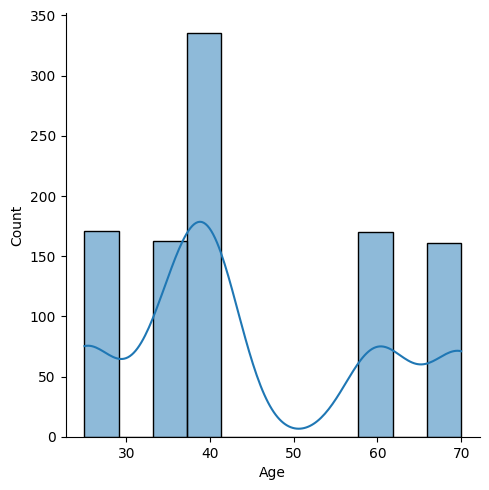

In [220]:
# distribution of the ages
plt.figure(figsize=(5,5))
sns.displot(hr, x='Age', kde=True)
plt.show()

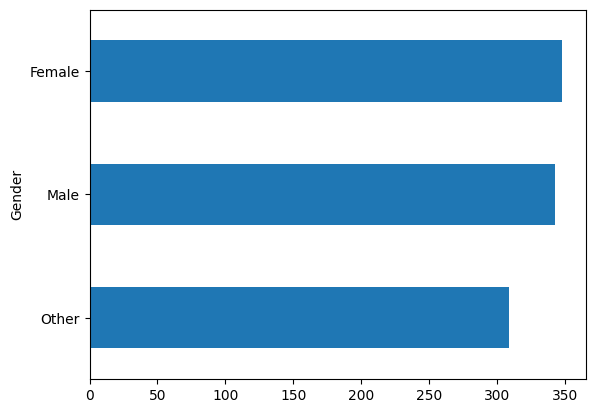

In [221]:
# sns.countplot(hr, x='Gender')
# plt.show()

hr['Gender'].value_counts().sort_values(ascending=True).plot(kind='barh')
plt.show()

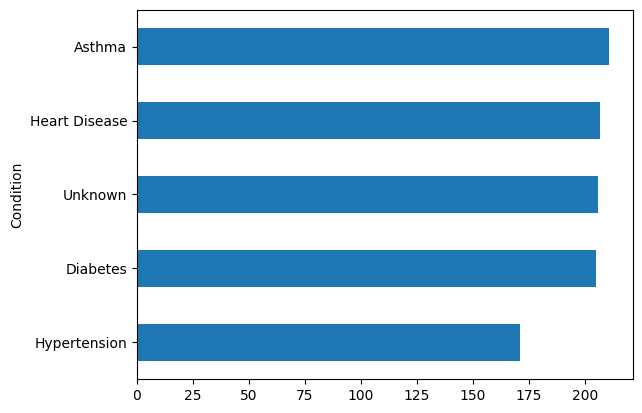

In [222]:
# sns.countplot(hr, x='Condition')
# plt.show()

hr['Condition'].value_counts().sort_values(ascending=True).plot(kind='barh')
plt.show()

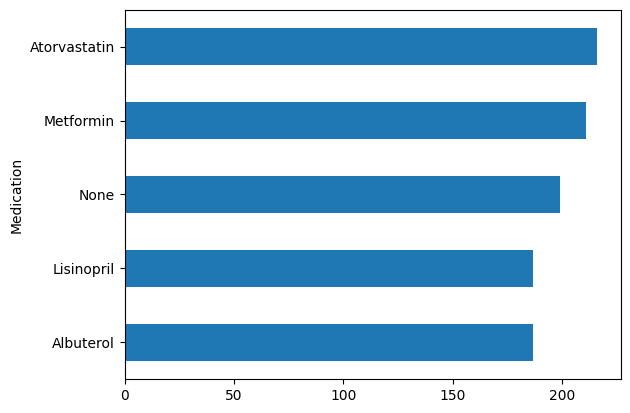

In [223]:
hr['Medication'].value_counts().sort_values(ascending=True).plot(kind='barh')
plt.show()

In [225]:
hr.to_csv('cleaned_health_dataset.csv', index=False)